# Обработка фото рисунка

In [10]:
%load_ext autoreload
%autoreload 2

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from utils import (
    detect_and_align, alignment_error, extract_colored,
    transfer_color, correct_photo, template_meta,
    image_rect_from_svg,
    build_triangulation, draw_triangulation,
    animate_character,
)

# --- конфиг персонажа ---
CHAR_ID = "004"
CHAR_DIR = f"templates/{CHAR_ID}"

SVG_PATH = f"{CHAR_DIR}/mask.svg"
TEMPLATE_SKELETON_PATH = f"{CHAR_DIR}/skeleton.json"
MOTION_PATH = f"{CHAR_DIR}/animation.json"

# --- конфиг фото ---
PHOTO_PATH = f"input/{CHAR_ID}_test2.HEIC"
CONTENT_SCALE = 0.8

# --- геометрия шаблона ---
CANVAS_SIZE = (1240, 1754)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
image_rect = image_rect_from_svg(SVG_PATH, meta, content_scale=CONTENT_SCALE)

print(f"image_rect: {image_rect}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
image_rect: [295, 264, 1163, 711]


## Шаг 1. Выравнивание по ArUco

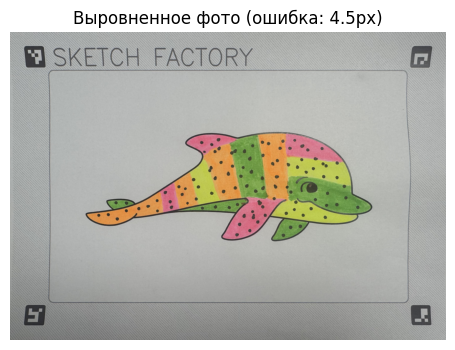

In [2]:
result = detect_and_align(PHOTO_PATH, meta)
aligned = result["aligned"]

mean_err, _ = alignment_error(aligned, meta)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Выровненное фото (ошибка: {mean_err:.1f}px)")
plt.savefig(f"output/{CHAR_ID}_aligned_demo.png", dpi=150, bbox_inches="tight")
plt.show()

## Шаг 2. Обрезка рисунка + Коррекция цвета


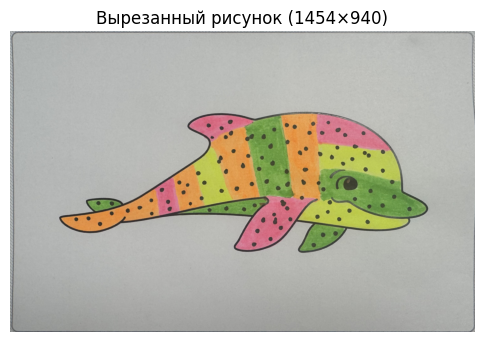

In [3]:
extracted = extract_colored(aligned, meta)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(extracted["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
rgba = extracted["rgba"]
plt.title(f"Вырезанный рисунок ({rgba.shape[1]}×{rgba.shape[0]})")
plt.show()

Бумага BGR: [179 181 178]
Gain BGR:   [1.3 1.3 1.3]


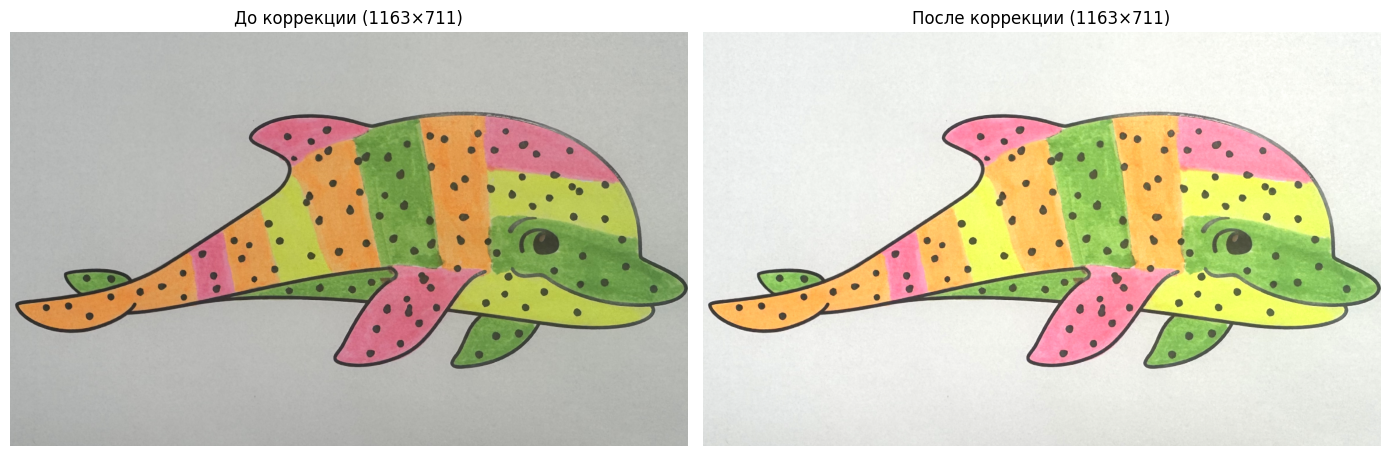

In [4]:
# Коррекция цвета: бумага = поля вокруг персонажа (между drawing_bbox и image_rect)
# Медиана цвета бумаги → поканальный gain = white_target / paper_median, клип gain_range

aligned_corrected, info = correct_photo(aligned, image_rect, meta, white_target=240, gain_range=(0.9, 1.3))
print(f"Бумага BGR: {info['paper_bgr'].astype(int)}")
print(f"Gain BGR:   {info['gain_bgr'].round(3)}")

ix, iy, iw, ih = image_rect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (img, title) in zip(axes, [
    (aligned[iy:iy+ih, ix:ix+iw], "До коррекции"),
    (aligned_corrected[iy:iy+ih, ix:ix+iw], "После коррекции"),
]):
    h, w = img.shape[:2]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title} ({w}×{h})")
    ax.axis("off")
plt.tight_layout(); plt.show()

In [5]:
# Сохраняем кроп drawing_bbox для RnD сегментации
x, y, w, h = meta["drawing_bbox"]
crop = aligned_corrected[y:y+h, x:x+w]

out = f"../rnd/input/seg_{CHAR_ID}_test1.png"
Path(out).parent.mkdir(exist_ok=True)
cv2.imwrite(out, crop)
print(f"Сохранено: {out} ({crop.shape[1]}×{crop.shape[0]})")

Сохранено: ../rnd/input/seg_004_test1.png (1454×940)


## Шаг 3. Перенос цветов на шаблон

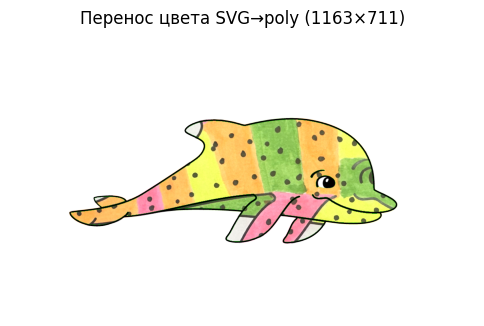

In [6]:
SVG_PATH = f"templates/{CHAR_ID}/mask.svg"

colored = transfer_color(aligned_corrected, SVG_PATH, image_rect)

rgba = colored["rgba"]
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(rgba, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title(f"Перенос цвета SVG→poly ({rgba.shape[1]}×{rgba.shape[0]})")
plt.show()

In [7]:
cv2.imwrite(f"output/{CHAR_ID}_colored.png", colored["rgba"])

True

Фото (среднее в зоне заливки): [110.95325839 194.60690392 212.48398749]
Результат (среднее в зоне заливки): [110.95325839 194.60690392 212.48398749]


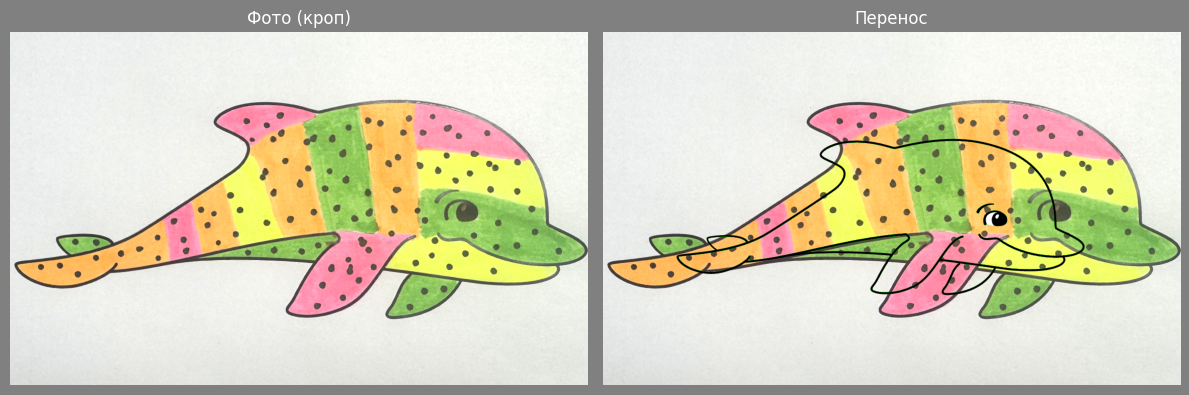

In [8]:
# Проверка: пиксели в зоне заливки должны совпадать
ix, iy, iw, ih = image_rect
photo_crop = aligned_corrected[iy:iy+ih, ix:ix+iw]
is_fill = colored["is_fill"]
print(f"Фото (среднее в зоне заливки): {photo_crop[is_fill].mean(axis=0)}")
print(f"Результат (среднее в зоне заливки): {colored['result'][is_fill].mean(axis=0)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='0.5')
for ax, (img, title) in zip(axes, [
    (photo_crop, "Фото (кроп)"),
    (colored["result"], "Перенос"),
]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, color='white')
    ax.set_facecolor('0.5')
    ax.axis("off")
plt.tight_layout(); plt.show()


Сохранено: output/004_colored_hi.png (4226×2256)


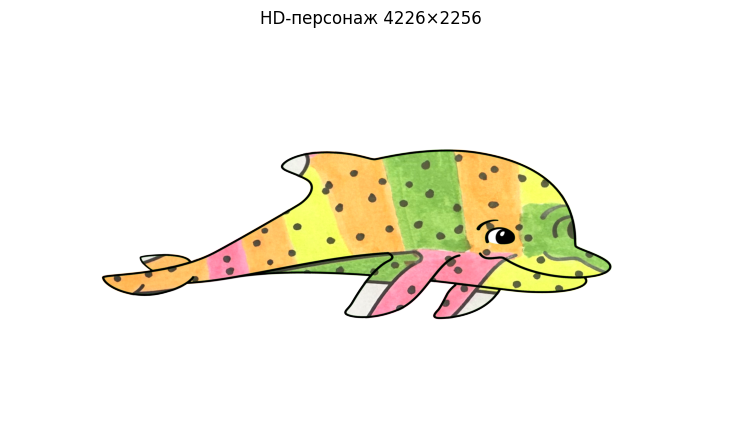

In [15]:
from utils import SvgCharacter

TARGET_W, TARGET_H = 4226, 2256

# 1) рендерим SVG в РОДНОМ аспекте (чтобы resvg не летtербоксил)
ix, iy, iw, ih = image_rect
render_h = TARGET_H
render_w = int(render_h * iw / ih)
svg_native = SvgCharacter(SVG_PATH).render(render_w, render_h, fill_zones="green")

# 2) теперь растягиваем raster до точного target (честный стретч)
svg_bgra = cv2.resize(svg_native, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

# 3) фото тоже под target
photo_crop = aligned_corrected[iy:iy+ih, ix:ix+iw]
photo_hi = cv2.resize(photo_crop, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

# 4) заливка цветами фото + композит (как в transfer_color)
b, g, r, a = svg_bgra[..., 0], svg_bgra[..., 1], svg_bgra[..., 2], svg_bgra[..., 3]
is_fill = (g > 200) & (r < 80) & (b < 80) & (a > 200)
svg_with_photo = svg_bgra.copy()
svg_with_photo[is_fill, :3] = photo_hi[is_fill]

alpha_f = svg_with_photo[..., 3:4].astype(np.float32) / 255.0
rgb = (svg_with_photo[..., :3].astype(np.float32) * alpha_f +
       photo_hi.astype(np.float32) * (1.0 - alpha_f)).astype(np.uint8)
colored_hi = cv2.merge([rgb[..., 0], rgb[..., 1], rgb[..., 2], svg_bgra[..., 3]])

# 5) сохранение + превью
Path("output").mkdir(exist_ok=True)
out_path = f"output/{CHAR_ID}_colored_hi.png"
cv2.imwrite(out_path, colored_hi)
print(f"Сохранено: {out_path} ({colored_hi.shape[1]}×{colored_hi.shape[0]})")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(colored_hi, cv2.COLOR_BGRA2RGBA))
plt.axis("off"); plt.title(f"HD-персонаж {TARGET_W}×{TARGET_H}")
plt.show()


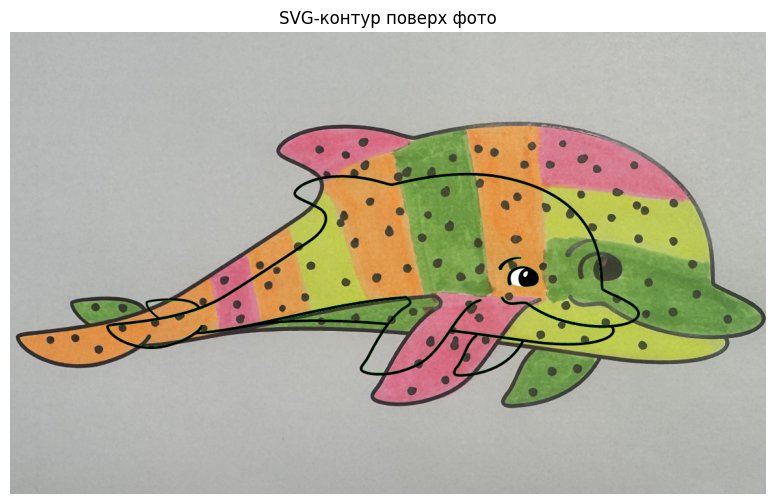

In [12]:
from svg import SvgCharacter   # или: from utils import SvgCharacter если так экспортирован

ix, iy, iw, ih = image_rect
svg_preview = SvgCharacter(SVG_PATH).render(iw, ih, fill_zones="transparent")
photo_crop = aligned[iy:iy+ih, ix:ix+iw].copy()

alpha = svg_preview[..., 3:4] / 255.0
overlay = (photo_crop * (1 - alpha) + svg_preview[..., :3] * alpha).astype(np.uint8)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.title("SVG-контур поверх фото")
plt.show()

In [13]:
print(f"CHAR_ID в конфиге: {CHAR_ID}")
print(f"bl_id из фото:      {result['bl_id']}")
print(f"ожидаемый bl_id для {CHAR_ID}: {3 + (int(CHAR_ID) - 1)}")


CHAR_ID в конфиге: 004
bl_id из фото:      6
ожидаемый bl_id для 004: 6


In [ ]:
print("template.png:", Path(f"{CHAR_DIR}/template.png").stat().st_mtime)
print("photo:       ", Path(PHOTO_PATH).stat().st_mtime)

template.png: 1776708286.6446013
photo:        1776707014.181663


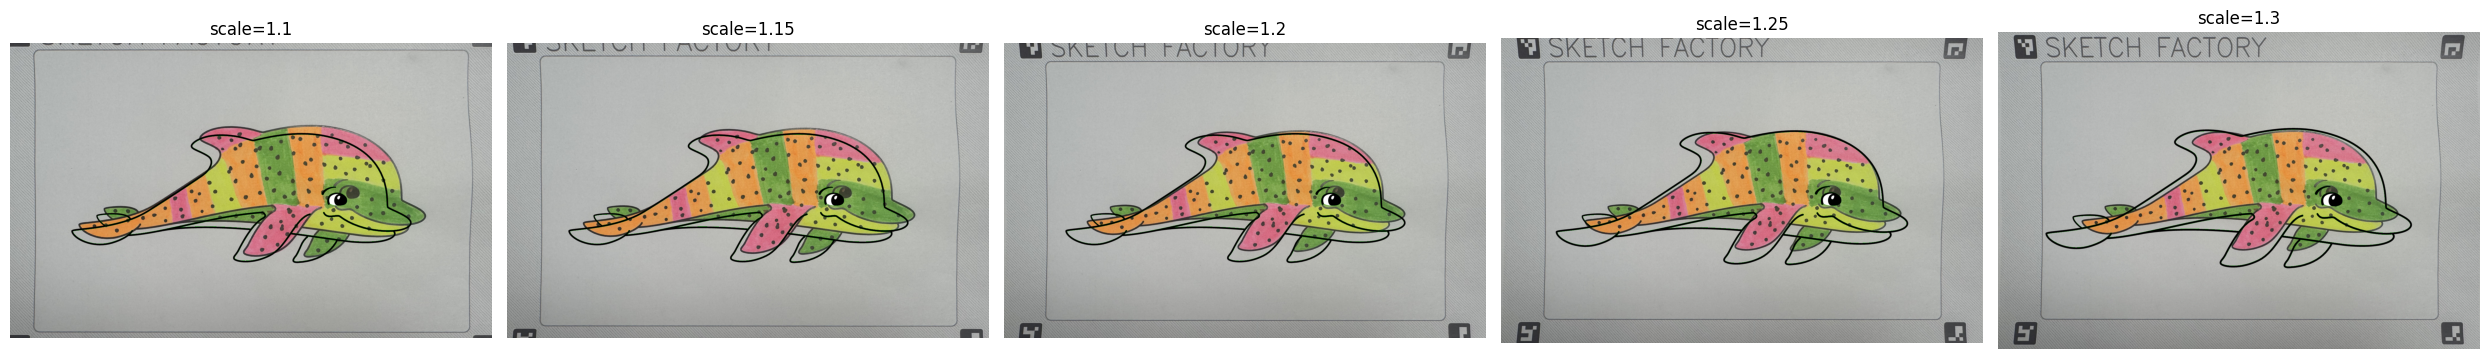

In [22]:
scales = [1.1, 1.15, 1.20, 1.25, 1.30]
fig, axes = plt.subplots(1, len(scales), figsize=(5 * len(scales), 5))
H, W = aligned.shape[:2]

for ax, cs in zip(axes, scales):
    ix, iy, iw, ih = image_rect_from_svg(SVG_PATH, meta, content_scale=cs)
    svg_full = SvgCharacter(SVG_PATH).render(iw, ih, fill_zones="transparent")

    # клипим прямоугольник по границам aligned
    x0, y0 = max(ix, 0), max(iy, 0)
    x1, y1 = min(ix + iw, W), min(iy + ih, H)
    cw, ch = x1 - x0, y1 - y0
    sx0, sy0 = x0 - ix, y0 - iy
    svg_p = svg_full[sy0:sy0+ch, sx0:sx0+cw]
    crop = aligned[y0:y1, x0:x1].copy()

    alpha = svg_p[..., 3:4] / 255.0
    overlay = (crop * (1 - alpha) + svg_p[..., :3] * alpha).astype(np.uint8)
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"scale={cs}")
    ax.axis("off")

plt.tight_layout(); plt.show()


IoU: 0.044 → 0.040   (scale=0.249, dx=439.5, dy=313.3)
Сохранено: output/004_colored_hi.png (4226×2256)


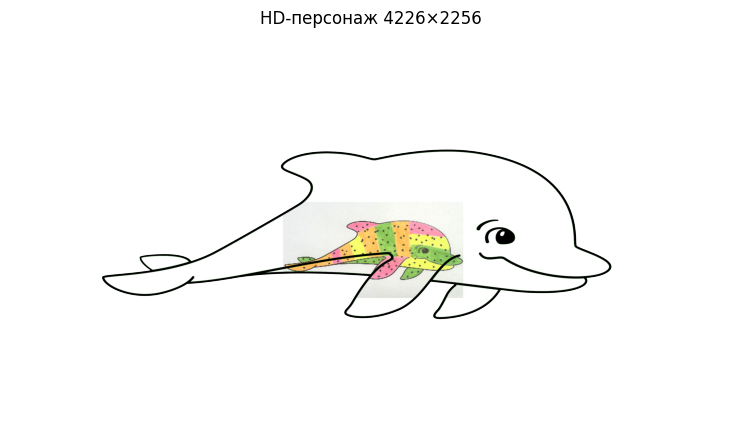

In [23]:
from utils import SvgCharacter

TARGET_W, TARGET_H = 4226, 2256

# --- 1. маски в координатах image_rect ---
ix, iy, iw, ih = image_rect
photo_crop = aligned_corrected[iy:iy+ih, ix:ix+iw]

# SVG-силуэт (всё непрозрачное)
svg_ref = SvgCharacter(SVG_PATH).render(iw, ih, fill_zones="transparent")
svg_mask = (svg_ref[..., 3] > 128).astype(np.uint8)

# нарисованное — не-белые пиксели
gray = cv2.cvtColor(photo_crop, cv2.COLOR_BGR2GRAY)
drawn_mask = (gray < 220).astype(np.uint8)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
drawn_mask = cv2.morphologyEx(drawn_mask, cv2.MORPH_CLOSE, k)
# оставляем крупнейшую компоненту (режем мусор)
n_cc, labels, stats, _ = cv2.connectedComponentsWithStats(drawn_mask)
if n_cc > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    drawn_mask = (labels == largest).astype(np.uint8)

# --- 2. similarity через моменты: translate + uniform scale ---
def centroid_area(mask):
    m = cv2.moments(mask)
    return m["m10"]/m["m00"], m["m01"]/m["m00"], m["m00"]

svg_cx, svg_cy, svg_area = centroid_area(svg_mask)
ph_cx, ph_cy, ph_area = centroid_area(drawn_mask)

scale = np.sqrt(svg_area / ph_area)  # сжать/растянуть photo под SVG
M = np.float32([
    [scale, 0, svg_cx - scale * ph_cx],
    [0, scale, svg_cy - scale * ph_cy],
])

photo_aligned = cv2.warpAffine(photo_crop, M, (iw, ih), borderValue=(255, 255, 255))
drawn_aligned = cv2.warpAffine(drawn_mask, M, (iw, ih))

iou_before = (svg_mask & drawn_mask).sum() / max(1, (svg_mask | drawn_mask).sum())
iou_after  = (svg_mask & drawn_aligned).sum() / max(1, (svg_mask | drawn_aligned).sum())
print(f"IoU: {iou_before:.3f} → {iou_after:.3f}   (scale={scale:.3f}, dx={M[0,2]:.1f}, dy={M[1,2]:.1f})")

# --- 3. HD-рендер из выровненного фото (как раньше) ---
render_h = TARGET_H
render_w = int(render_h * iw / ih)
svg_native = SvgCharacter(SVG_PATH).render(render_w, render_h, fill_zones="green")
svg_bgra = cv2.resize(svg_native, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

photo_hi = cv2.resize(photo_aligned, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LANCZOS4)

b, g, r, a = svg_bgra[..., 0], svg_bgra[..., 1], svg_bgra[..., 2], svg_bgra[..., 3]
is_fill = (g > 200) & (r < 80) & (b < 80) & (a > 200)
svg_with_photo = svg_bgra.copy()
svg_with_photo[is_fill, :3] = photo_hi[is_fill]

alpha_f = svg_with_photo[..., 3:4].astype(np.float32) / 255.0
rgb = (svg_with_photo[..., :3].astype(np.float32) * alpha_f +
       photo_hi.astype(np.float32) * (1.0 - alpha_f)).astype(np.uint8)
colored_hi = cv2.merge([rgb[..., 0], rgb[..., 1], rgb[..., 2], svg_bgra[..., 3]])

Path("output").mkdir(exist_ok=True)
out_path = f"output/{CHAR_ID}_colored_hi.png"
cv2.imwrite(out_path, colored_hi)
print(f"Сохранено: {out_path} ({colored_hi.shape[1]}×{colored_hi.shape[0]})")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(colored_hi, cv2.COLOR_BGRA2RGBA))
plt.axis("off"); plt.title(f"HD-персонаж {TARGET_W}×{TARGET_H}")
plt.show()


## Шаг 5. Скелет + триангуляция

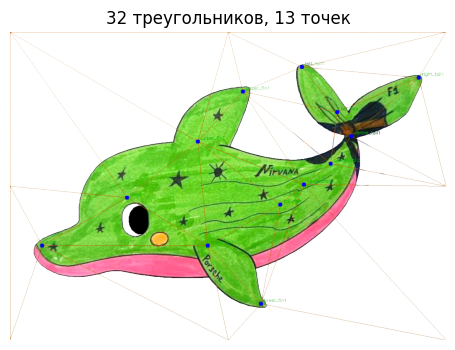

In [169]:
with open(TEMPLATE_SKELETON_PATH, encoding="utf-8") as f:
    keypoints = json.load(f)["keypoints"]

th, tw = colored["rgba"].shape[:2]
ctrl_pts, tri, n_kp, names = build_triangulation(keypoints, tw, th)

vis = draw_triangulation(colored["rgba"], ctrl_pts, tri, n_kp, names)

plt.figure(figsize=(6, 4))
plt.imshow(vis)  # уже RGBA, без конвертации
plt.axis("off")
plt.title(f"{len(tri.simplices)} треугольников, {n_kp} точек")
plt.show()

## Шаг 6. Анимация

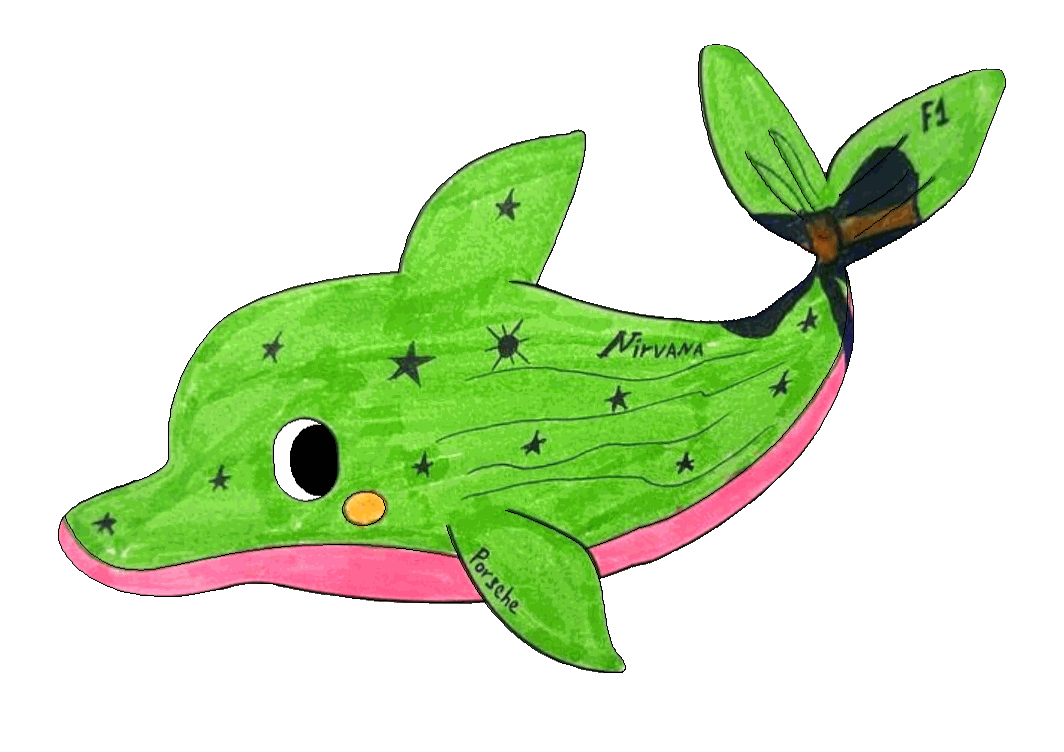

In [170]:
from IPython.display import Image as IPImage, display

# загружаем motion config
with open(MOTION_PATH, encoding="utf-8") as f:
    motion_cfg = json.load(f)

# анимируем (colored["rgba"] из предыдущей ячейки)
frames = animate_character(colored["rgba"], keypoints, motion_cfg)

# сохраняем GIF
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
gif_path = f"output/{CHAR_ID}_anim.gif"
pil_frames[0].save(gif_path, save_all=True, append_images=pil_frames[1:],
                   duration=1000 // 15, loop=0, disposal=2)
display(IPImage(filename=gif_path, width=500))